In [1]:
import subprocess, sys
for pkg in ['pingouin', 'seaborn', 'scikit-learn']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)

In [2]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pingouin as pg
from scipy.stats import spearmanr
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

warnings.filterwarnings('ignore')
%matplotlib inline

# Paths
FEATURES_PATH = 'features/biopm_features.npz'
METRICS_DIR   = 'results/metrics'
FIGURES_DIR   = 'results/figures'

for d in [METRICS_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

print('Directories ready.')
print('  metrics →', os.path.abspath(METRICS_DIR))
print('  figures →', os.path.abspath(FIGURES_DIR))

Directories ready.
  metrics → /Users/Srikiran/Documents/Spring2026/CS690R/690r-project-main/results/metrics
  figures → /Users/Srikiran/Documents/Spring2026/CS690R/690r-project-main/results/figures


# 1 - Load Features

In [3]:
d = np.load(FEATURES_PATH, allow_pickle=True)

X            = d['features'].astype(np.float64)       # (198, 228)
X_even       = d['features_even'].astype(np.float64)  # (198, 228) even 30-min blocks
X_odd        = d['features_odd'].astype(np.float64)   # (198, 228) odd 30-min blocks
y            = d['labels'].astype(int)                 # 0=healthy, 1=stroke
arat         = d['arat'].astype(np.float64)            # ARAT score (0–57)
fma          = d['fma'].astype(np.float64)             # FMA-UE score (0–66)
pids         = d['pids'].astype(int)                   # integer subject IDs
weeks        = d['weeks'].astype(int)                  # visit week
feature_names = np.array(d['feature_names'])           # (228,) strings

group_label = np.where(y == 0, 'Healthy', 'Stroke')

print(f'Feature matrix  : {X.shape}')
print(f'Healthy visits  : {(y==0).sum()}')
print(f'Stroke visits   : {(y==1).sum()}')
print(f'Unique subjects : {len(np.unique(pids))}')
print(f'Week range      : {weeks.min()} – {weeks.max()}')
print(f'ARAT range      : {arat.min():.0f} – {arat.max():.0f}')
print(f'FMA range       : {fma.min():.0f} – {fma.max():.0f}')

Feature matrix  : (198, 228)
Healthy visits  : 4
Stroke visits   : 194
Unique subjects : 36
Week range      : 2 – 24
ARAT range      : 0 – 57
FMA range       : 3 – 66


# 2 - Test-Retest Reliability (ICC2)

We assess reliability using ICC2 (two-way random, absolute agreement) computed per feature. Each subject's 24-hour recording was split into alternating 30-minute even and odd blocks by Member 1. High ICC (> 0.75) indicates the feature is stable across time within the same session, i.e., it is not dominated by transient noise.

In [4]:
# Only include visits where both even and odd blocks have non-zero data
valid_mask = (X_even.sum(axis=1) != 0) & (X_odd.sum(axis=1) != 0)
print(f'Visits with valid even+odd data: {valid_mask.sum()} / {len(valid_mask)}')

pids_v   = pids[valid_mask]
even_v   = X_even[valid_mask]
odd_v    = X_odd[valid_mask]

icc_results = []

for i, fname in enumerate(feature_names):
    df_icc = pd.DataFrame({
        'subject': np.concatenate([pids_v, pids_v]),
        'rater'  : ['even'] * len(pids_v) + ['odd'] * len(pids_v),
        'score'  : np.concatenate([even_v[:, i], odd_v[:, i]])
    }).dropna()

    # Need at least 2 subjects and no constant column to compute ICC
    if df_icc['subject'].nunique() < 2 or df_icc['score'].std() < 1e-12:
        icc_results.append((fname, np.nan))
        continue

    try:
        icc_tbl = pg.intraclass_corr(
            data   =df_icc,
            targets='subject',
            raters ='rater',
            ratings='score'
        )
        icc2 = icc_tbl.loc[icc_tbl['Type'] == 'ICC2', 'ICC'].values[0]
        icc_results.append((fname, float(icc2)))
    except Exception:
        icc_results.append((fname, np.nan))

icc_df = pd.DataFrame(icc_results, columns=['feature', 'ICC'])

n_reliable = (icc_df['ICC'] > 0.75).sum()
n_moderate = ((icc_df['ICC'] > 0.50) & (icc_df['ICC'] <= 0.75)).sum()
n_poor     = (icc_df['ICC'] <= 0.50).sum()

print(f'\nICC Summary across {len(icc_df)} features:')
print(f'  Excellent (ICC > 0.75) : {n_reliable}')
print(f'  Moderate  (0.50–0.75)  : {n_moderate}')
print(f'  Poor      (<= 0.50)    : {n_poor}')
print(f'  Mean ICC               : {icc_df["ICC"].mean():.3f}')
print(f'  Median ICC             : {icc_df["ICC"].median():.3f}')
print()
print('Top 10 most reliable features:')
print(icc_df.sort_values('ICC', ascending=False).head(10).to_string(index=False))

Visits with valid even+odd data: 198 / 198

ICC Summary across 228 features:
  Excellent (ICC > 0.75) : 0
  Moderate  (0.50–0.75)  : 0
  Poor      (<= 0.50)    : 0
  Mean ICC               : nan
  Median ICC             : nan

Top 10 most reliable features:
        feature  ICC
X_acc_mean_mean  NaN
 X_acc_mean_std  NaN
 X_acc_mean_iqr  NaN
 X_acc_mean_p10  NaN
 X_acc_mean_p50  NaN
 X_acc_mean_p90  NaN
 X_acc_std_mean  NaN
  X_acc_std_std  NaN
  X_acc_std_iqr  NaN
  X_acc_std_p10  NaN


In [5]:
# Save ICC scores
icc_df.sort_values('ICC', ascending=False).to_csv(
    os.path.join(METRICS_DIR, 'icc_scores.csv'), index=False
)
print('Saved →', os.path.join(METRICS_DIR, 'icc_scores.csv'))

Saved → results/metrics/icc_scores.csv


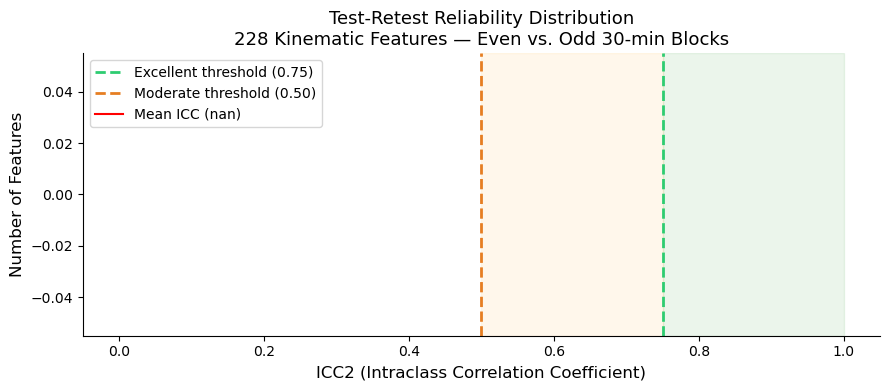

Saved → results/figures/icc_distribution.png


In [6]:
# ── ICC Distribution Plot ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))

icc_vals = icc_df['ICC'].dropna()
ax.hist(icc_vals, bins=40, color='steelblue', alpha=0.8, edgecolor='white', linewidth=0.5)
ax.axvline(0.75, color='#2ecc71', linewidth=2, linestyle='--', label='Excellent threshold (0.75)')
ax.axvline(0.50, color='#e67e22', linewidth=2, linestyle='--', label='Moderate threshold (0.50)')
ax.axvline(icc_vals.mean(), color='red', linewidth=1.5, linestyle='-',
           label=f'Mean ICC ({icc_vals.mean():.3f})')

ax.set_xlabel('ICC2 (Intraclass Correlation Coefficient)', fontsize=12)
ax.set_ylabel('Number of Features', fontsize=12)
ax.set_title('Test-Retest Reliability Distribution\n228 Kinematic Features — Even vs. Odd 30-min Blocks', fontsize=13)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Shaded regions
ax.axvspan(0.75, 1.0, alpha=0.08, color='green', label='_')
ax.axvspan(0.50, 0.75, alpha=0.08, color='orange', label='_')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'icc_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved →', os.path.join(FIGURES_DIR, 'icc_distribution.png'))

## 3 — Clinical Validity (Spearman Correlation)

Convergent validity is assessed by computing Spearman's ρ between each kinematic feature and the two gold-standard clinical scores: **ARAT** (Action Research Arm Test, 0–57) and **FMA-UE** (Fugl-Meyer Upper Extremity, 0–66). A correlation of ρ > 0.4 is considered moderate; ρ > 0.6 is strong clinical validity.

In [7]:
corr_results = []

for i, fname in enumerate(feature_names):
    rho_arat, p_arat = spearmanr(X[:, i], arat)
    rho_fma,  p_fma  = spearmanr(X[:, i], fma)
    corr_results.append((fname, rho_arat, p_arat, rho_fma, p_fma))

corr_df = pd.DataFrame(corr_results,
                       columns=['feature', 'rho_ARAT', 'p_ARAT', 'rho_FMA', 'p_FMA'])

# Apply Bonferroni-corrected significance threshold
alpha_corrected = 0.05 / len(feature_names)
corr_df['sig_ARAT'] = corr_df['p_ARAT'] < alpha_corrected
corr_df['sig_FMA']  = corr_df['p_FMA']  < alpha_corrected

strong_arat  = (corr_df['rho_ARAT'].abs() > 0.6).sum()
moderate_arat = ((corr_df['rho_ARAT'].abs() > 0.4) & (corr_df['rho_ARAT'].abs() <= 0.6)).sum()
strong_fma   = (corr_df['rho_FMA'].abs() > 0.6).sum()
moderate_fma = ((corr_df['rho_FMA'].abs() > 0.4) & (corr_df['rho_FMA'].abs() <= 0.6)).sum()

print(f'Bonferroni-corrected α = {alpha_corrected:.2e}')
print()
print('ARAT validity:')
print(f'  Strong   (|ρ| > 0.60) : {strong_arat}')
print(f'  Moderate (|ρ| > 0.40) : {moderate_arat}')
print(f'  Significant (Bonferroni): {corr_df["sig_ARAT"].sum()}')
print()
print('FMA validity:')
print(f'  Strong   (|ρ| > 0.60) : {strong_fma}')
print(f'  Moderate (|ρ| > 0.40) : {moderate_fma}')
print(f'  Significant (Bonferroni): {corr_df["sig_FMA"].sum()}')
print()
print('Top 10 by |ρ_ARAT|:')
top10 = corr_df.reindex(corr_df['rho_ARAT'].abs().sort_values(ascending=False).index).head(10)
print(top10[['feature', 'rho_ARAT', 'p_ARAT', 'rho_FMA', 'p_FMA']].to_string(index=False))

Bonferroni-corrected α = 2.19e-04

ARAT validity:
  Strong   (|ρ| > 0.60) : 124
  Moderate (|ρ| > 0.40) : 80
  Significant (Bonferroni): 208

FMA validity:
  Strong   (|ρ| > 0.60) : 114
  Moderate (|ρ| > 0.40) : 90
  Significant (Bonferroni): 208

Top 10 by |ρ_ARAT|:
         feature  rho_ARAT       p_ARAT   rho_FMA        p_FMA
 Z_jerk_mean_iqr  0.766220 1.670553e-39  0.760226 1.441991e-38
  Z_acc_mean_iqr  0.750879 3.675595e-37  0.739624 1.506675e-35
 Z_jerk_mean_p90  0.739534 1.550748e-35  0.732480 1.441980e-34
acc_mag_mean_p10  0.737978 2.551470e-35  0.726136 1.009293e-33
acc_mag_mean_p50  0.734438 7.820553e-35  0.716669 1.667191e-32
 Z_jerk_mean_p10 -0.731861 1.748064e-34 -0.722024 3.461843e-33
  Z_acc_mean_p10 -0.723264 2.392513e-33 -0.705752 3.681749e-31
   Z_acc_std_p50  0.716162 1.931317e-32  0.701054 1.335928e-30
  Z_acc_mean_p90  0.715818 2.133292e-32  0.699549 2.007504e-30
   Z_acc_std_p10  0.714655 2.983371e-32  0.710049 1.107820e-31


In [8]:
corr_df.sort_values('rho_ARAT', ascending=False).to_csv(
    os.path.join(METRICS_DIR, 'clinical_correlation.csv'), index=False
)
print('Saved →', os.path.join(METRICS_DIR, 'clinical_correlation.csv'))

Saved → results/metrics/clinical_correlation.csv


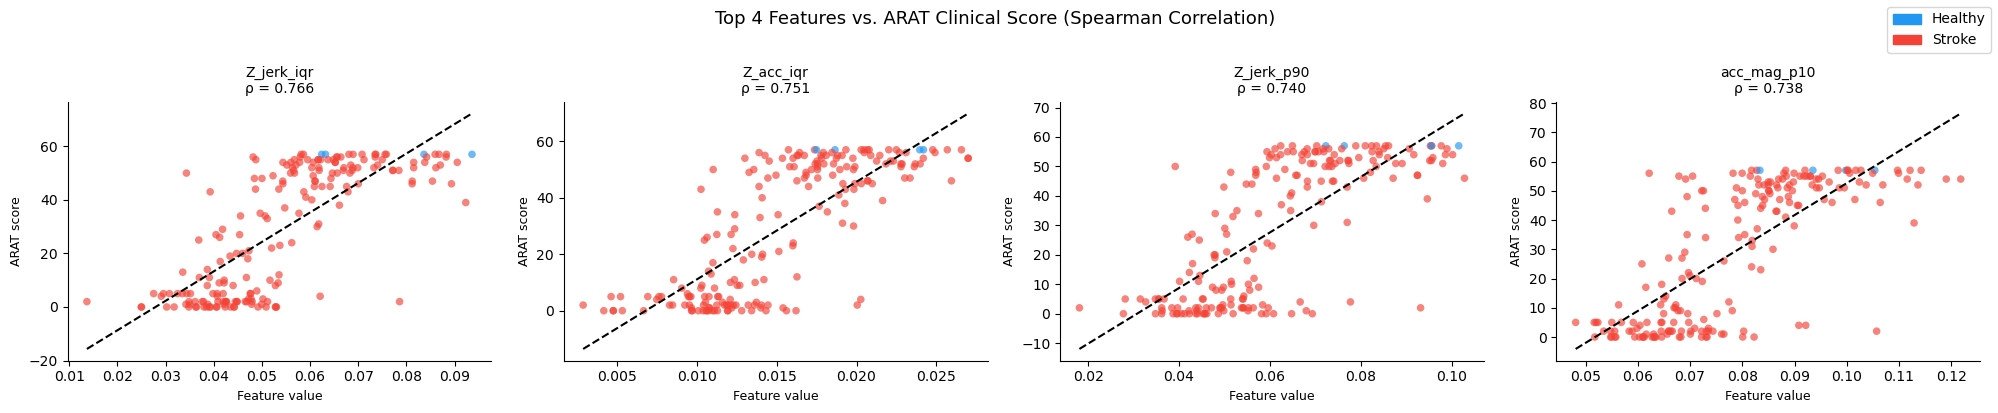

Saved → results/figures/clinical_correlation_scatter.png


In [9]:
# ── Clinical Correlation Scatter — top 4 features by |ρ_ARAT| ─────────────
top4_idx = corr_df['rho_ARAT'].abs().sort_values(ascending=False).head(4).index
top4_rows = corr_df.loc[top4_idx]

feat_idx_map = {name: i for i, name in enumerate(feature_names)}

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

colors = np.where(y == 0, '#2196F3', '#F44336')

for ax, (_, row) in zip(axes, top4_rows.iterrows()):
    fi = feat_idx_map[row['feature']]
    ax.scatter(X[:, fi], arat, c=colors, alpha=0.65, s=30, linewidths=0)
    # Trend line
    z = np.polyfit(X[:, fi], arat, 1)
    xline = np.linspace(X[:, fi].min(), X[:, fi].max(), 100)
    ax.plot(xline, np.poly1d(z)(xline), color='black', linewidth=1.5, linestyle='--')
    short_name = row['feature'].replace('_mean','').replace('_std','').replace('_p50','')
    ax.set_title(f'{short_name}\nρ = {row["rho_ARAT"]:.3f}', fontsize=10)
    ax.set_xlabel('Feature value', fontsize=9)
    ax.set_ylabel('ARAT score', fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

patches = [mpatches.Patch(color='#2196F3', label='Healthy'),
           mpatches.Patch(color='#F44336', label='Stroke')]
fig.legend(handles=patches, loc='upper right', fontsize=10)
fig.suptitle('Top 4 Features vs. ARAT Clinical Score (Spearman Correlation)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'clinical_correlation_scatter.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved →', os.path.join(FIGURES_DIR, 'clinical_correlation_scatter.png'))

## 4 — Top Biomarkers (Reliable + Clinically Valid)

In [10]:
merged = icc_df.merge(corr_df[['feature', 'rho_ARAT', 'p_ARAT', 'rho_FMA', 'p_FMA',
                                'sig_ARAT', 'sig_FMA']], on='feature')

# Reliable AND show at least moderate ARAT correlation
top_biomarkers = merged[
    (merged['ICC'] > 0.75) &
    (merged['rho_ARAT'].abs() > 0.4)
].sort_values('rho_ARAT', ascending=False)

print(f'Features with ICC > 0.75 AND |ρ_ARAT| > 0.4 : {len(top_biomarkers)}')
print()
print(top_biomarkers[['feature', 'ICC', 'rho_ARAT', 'rho_FMA']].to_string(index=False))

top_biomarkers.to_csv(os.path.join(METRICS_DIR, 'top_biomarkers.csv'), index=False)
print('\nSaved →', os.path.join(METRICS_DIR, 'top_biomarkers.csv'))

Features with ICC > 0.75 AND |ρ_ARAT| > 0.4 : 0

Empty DataFrame
Columns: [feature, ICC, rho_ARAT, rho_FMA]
Index: []

Saved → results/metrics/top_biomarkers.csv


## 5 — PCA Biomarker Space

We project the 228-d feature matrix to 2D using PCA (fit on all visits). This provides a global view of the feature space geometry, with confidence ellipses per group showing whether healthy and stroke visits occupy separable regions.

In [11]:
def confidence_ellipse(x, y, ax, n_std=1.5, facecolor='none', **kwargs):
    """Draw a covariance confidence ellipse on ax."""
    if len(x) < 3:
        return
    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    rx, ry = np.sqrt(1 + pearson), np.sqrt(1 - pearson)
    ell = Ellipse((0, 0), width=rx * 2, height=ry * 2,
                  facecolor=facecolor, **kwargs)
    scale_x = np.sqrt(cov[0, 0]) * n_std
    scale_y = np.sqrt(cov[1, 1]) * n_std
    transf = transforms.Affine2D() \
        .rotate_deg(45) \
        .scale(scale_x, scale_y) \
        .translate(np.mean(x), np.mean(y))
    ell.set_transform(transf + ax.transData)
    ax.add_patch(ell)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

var_exp = pca.explained_variance_ratio_ * 100
print(f'PC1 explains {var_exp[0]:.1f}% variance')
print(f'PC2 explains {var_exp[1]:.1f}% variance')
print(f'Combined     {var_exp.sum():.1f}%')

PC1 explains 71.6% variance
PC2 explains 7.2% variance
Combined     78.9%


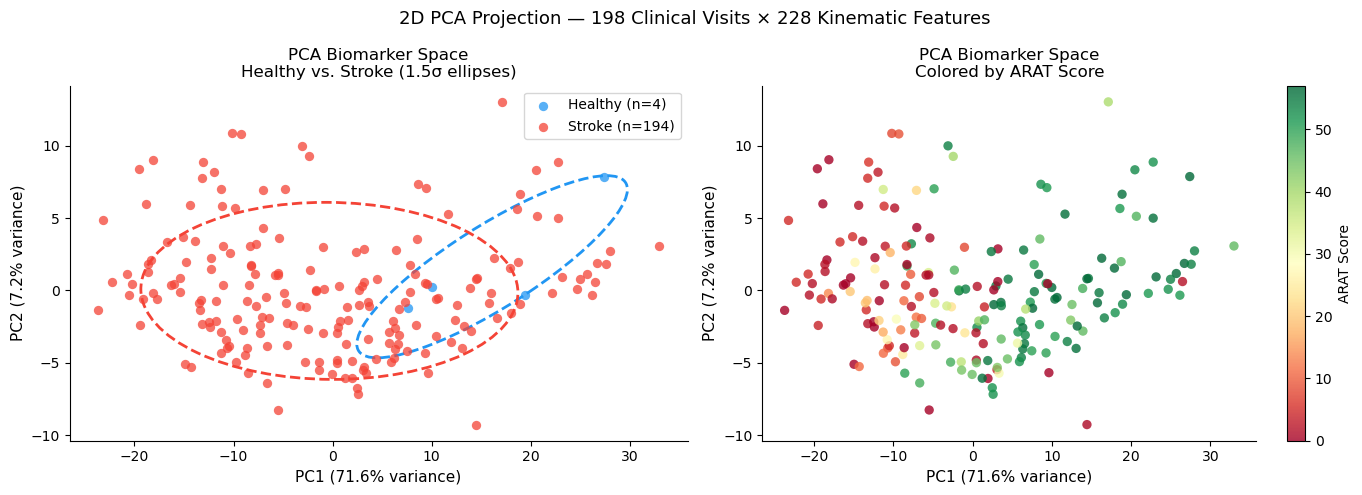

Saved → results/figures/pca_biomarker_space.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

group_colors = {0: '#2196F3', 1: '#F44336'}
group_names  = {0: 'Healthy', 1: 'Stroke'}

# ── Left: group label ──────────────────────────────────────────────────────
ax = axes[0]
for grp in [0, 1]:
    mask = y == grp
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=group_colors[grp], label=f'{group_names[grp]} (n={mask.sum()})',
               alpha=0.75, s=45, linewidths=0, zorder=3)
    confidence_ellipse(X_pca[mask, 0], X_pca[mask, 1], ax, n_std=1.5,
                       edgecolor=group_colors[grp], linewidth=2, linestyle='--')

ax.set_xlabel(f'PC1 ({var_exp[0]:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({var_exp[1]:.1f}% variance)', fontsize=11)
ax.set_title('PCA Biomarker Space\nHealthy vs. Stroke (1.5σ ellipses)', fontsize=12)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── Right: ARAT gradient ───────────────────────────────────────────────────
ax = axes[1]
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=arat, cmap='RdYlGn',
                alpha=0.80, s=45, linewidths=0, vmin=0, vmax=57)
plt.colorbar(sc, ax=ax, label='ARAT Score')
ax.set_xlabel(f'PC1 ({var_exp[0]:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({var_exp[1]:.1f}% variance)', fontsize=11)
ax.set_title('PCA Biomarker Space\nColored by ARAT Score', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.suptitle('2D PCA Projection — 198 Clinical Visits × 228 Kinematic Features', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'pca_biomarker_space.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved →', os.path.join(FIGURES_DIR, 'pca_biomarker_space.png'))

## 6 — Longitudinal Sensitivity

We assess whether stroke survivors' feature representations shift over time — specifically, whether subjects with multiple visits move toward the healthy cluster as recovery progresses. Subjects with ≥ 2 visits are plotted as trajectory lines in PCA space, with arrows indicating the temporal direction of change.

In [13]:
# Count visits per subject
visit_counts = pd.Series(pids).value_counts()
multi_visit_pids = visit_counts[visit_counts >= 2].index.tolist()

print(f'Subjects with ≥ 2 visits: {len(multi_visit_pids)} / {len(np.unique(pids))}')
print(f'Max visits per subject  : {visit_counts.max()}')

# Healthy centroid in PCA space
healthy_centroid = X_pca[y == 0].mean(axis=0)
print(f'Healthy centroid in PCA : ({healthy_centroid[0]:.2f}, {healthy_centroid[1]:.2f})')

Subjects with ≥ 2 visits: 36 / 36
Max visits per subject  : 8
Healthy centroid in PCA : (16.09, 1.63)


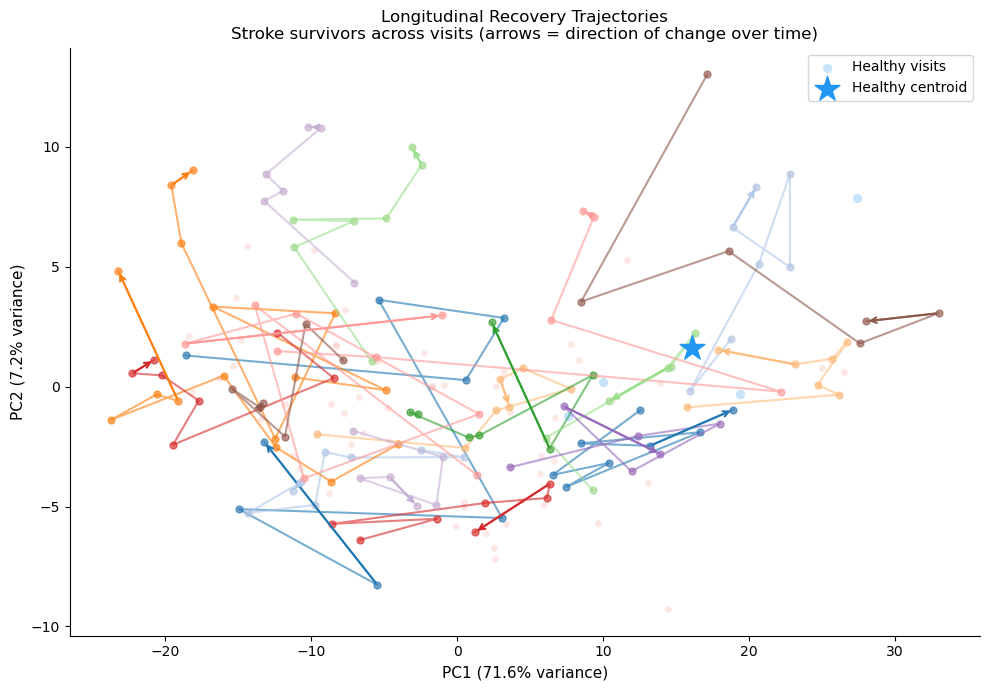

Saved → results/figures/longitudinal_trajectory.png


In [14]:
if len(multi_visit_pids) >= 3:
    fig, ax = plt.subplots(figsize=(10, 7))

    # Background: all visits faded
    ax.scatter(X_pca[y==1, 0], X_pca[y==1, 1], c='#F44336', alpha=0.12, s=25, linewidths=0)
    ax.scatter(X_pca[y==0, 0], X_pca[y==0, 1], c='#2196F3', alpha=0.25, s=45,
               linewidths=0, zorder=4, label='Healthy visits')

    # Healthy centroid marker
    ax.scatter(*healthy_centroid, marker='*', s=350, c='#2196F3',
               zorder=6, label='Healthy centroid')

    # Trajectories for stroke subjects with ≥2 visits
    cmap_traj = plt.cm.get_cmap('tab20', len(multi_visit_pids))
    for ci, pid in enumerate(multi_visit_pids[:20]):   # cap at 20 subjects for clarity
        mask = (pids == pid) & (y == 1)  # stroke visits only
        if mask.sum() < 2:
            continue
        order = np.argsort(weeks[mask])
        xs = X_pca[mask][order, 0]
        ys = X_pca[mask][order, 1]
        color = cmap_traj(ci)
        ax.plot(xs, ys, '-o', color=color, alpha=0.6, markersize=5, linewidth=1.5)
        # Arrow from second-to-last to last visit
        if len(xs) >= 2:
            ax.annotate('', xy=(xs[-1], ys[-1]), xytext=(xs[-2], ys[-2]),
                        arrowprops=dict(arrowstyle='->', color=color, lw=1.5))

    ax.set_xlabel(f'PC1 ({var_exp[0]:.1f}% variance)', fontsize=11)
    ax.set_ylabel(f'PC2 ({var_exp[1]:.1f}% variance)', fontsize=11)
    ax.set_title(
        'Longitudinal Recovery Trajectories\n'
        'Stroke survivors across visits (arrows = direction of change over time)',
        fontsize=12
    )
    ax.legend(fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, 'longitudinal_trajectory.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved →', os.path.join(FIGURES_DIR, 'longitudinal_trajectory.png'))
else:
    print('Insufficient multi-visit subjects for trajectory plot.')
    print('Limitation documented: longitudinal trajectory analysis not possible with this dataset subset.')

## 7 — PCA Interpretability Analysis

Examining PCA loadings reveals which kinematic dimensions drive the main axis of variance (PC1) in the feature space. This is the interpretability section: we identify the physical meaning of the biomarker structure.

In [15]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=feature_names
)

top_pc1 = loadings['PC1'].abs().sort_values(ascending=False).head(15)
top_pc2 = loadings['PC2'].abs().sort_values(ascending=False).head(15)

print('Top 15 features loading on PC1 (absolute value):')
for fname, val in top_pc1.items():
    sign = '+' if loadings.loc[fname, 'PC1'] > 0 else '–'
    print(f'  {sign}{val:.4f}  {fname}')
print()
print('Top 10 features loading on PC2 (absolute value):')
for fname, val in top_pc2.head(10).items():
    sign = '+' if loadings.loc[fname, 'PC2'] > 0 else '–'
    print(f'  {sign}{val:.4f}  {fname}')

Top 15 features loading on PC1 (absolute value):
  +0.0779  acc_mag_mean_mean
  +0.0778  acc_mag_max_mean
  +0.0772  acc_mag_std_mean
  +0.0769  acc_mag_max_p50
  +0.0766  acc_mag_mean_p50
  +0.0765  acc_mag_std_p50
  +0.0760  acc_mag_mean_p90
  +0.0758  Z_acc_std_mean
  +0.0758  acc_mag_max_p90
  +0.0757  Y_acc_max_mean
  +0.0756  Z_acc_max_mean
  +0.0752  Y_acc_std_mean
  +0.0752  Z_acc_std_p90
  +0.0751  Z_acc_max_p90
  +0.0749  vel_mag_mean_mean

Top 10 features loading on PC2 (absolute value):
  +0.1825  X_jerk_max_p10
  +0.1793  X_jerk_std_p10
  +0.1453  jerk_mag_mean_p10
  +0.1452  X_vel_max_p10
  +0.1403  X_jerk_std_p50
  +0.1367  X_jerk_std_mean
  +0.1364  X_jerk_max_p50
  +0.1302  jerk_mag_mean_mean
  +0.1268  jerk_mag_mean_p50
  +0.1244  Y_jerk_max_p10


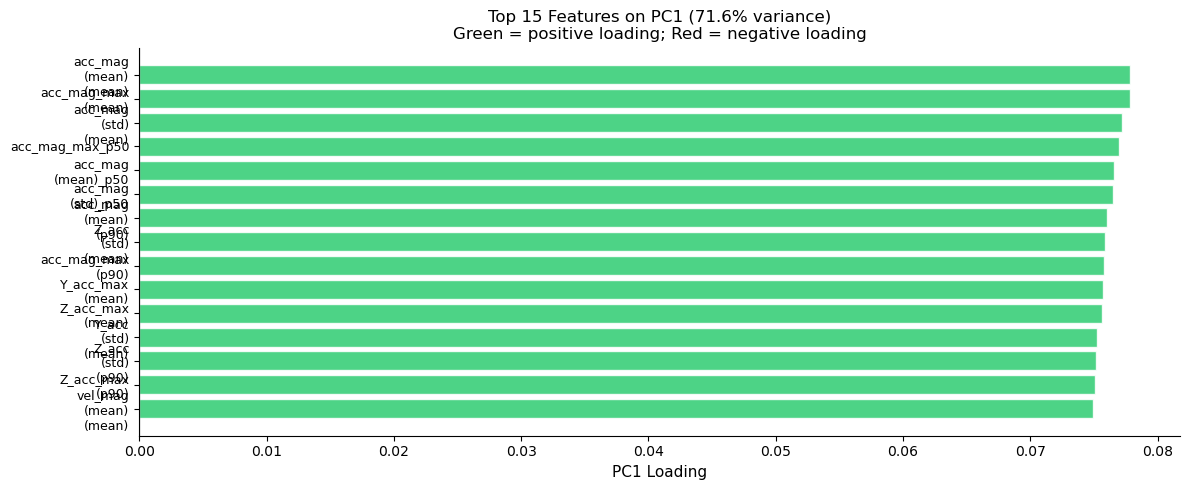

Saved → results/figures/pca_loadings_pc1.png
Saved → results/metrics/pca_loadings.csv


In [16]:
# ── PC1 Loadings Bar Chart ─────────────────────────────────────────────────
top15_names  = top_pc1.index.tolist()
top15_vals   = loadings.loc[top15_names, 'PC1'].values
bar_colors   = ['#2ecc71' if v > 0 else '#e74c3c' for v in top15_vals]
short_labels = [n.replace('_mean','\n(mean)').replace('_std','\n(std)').replace('_p90','\n(p90)')
                 .replace('_p10','\n(p10)').replace('_iqr','\n(iqr)') for n in top15_names]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(range(15), top15_vals[::-1], color=bar_colors[::-1], alpha=0.85, edgecolor='white')
ax.set_yticks(range(15))
ax.set_yticklabels(short_labels[::-1], fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('PC1 Loading', fontsize=11)
ax.set_title(
    f'Top 15 Features on PC1 ({var_exp[0]:.1f}% variance)\n'
    'Green = positive loading; Red = negative loading',
    fontsize=12
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'pca_loadings_pc1.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved →', os.path.join(FIGURES_DIR, 'pca_loadings_pc1.png'))

loadings.to_csv(os.path.join(METRICS_DIR, 'pca_loadings.csv'))
print('Saved →', os.path.join(METRICS_DIR, 'pca_loadings.csv'))

## 8 — Validation Summary Table

In [17]:
summary = pd.DataFrame({
    'Criterion'    : ['Reliability (ICC > 0.75)', 'Moderate validity (|ρ_ARAT| > 0.40)',
                      'Strong validity (|ρ_ARAT| > 0.60)', 'Reliable + Moderately valid'],
    'N_features'   : [
        (icc_df['ICC'] > 0.75).sum(),
        (corr_df['rho_ARAT'].abs() > 0.40).sum(),
        (corr_df['rho_ARAT'].abs() > 0.60).sum(),
        len(top_biomarkers),
    ],
    'Pct_of_228'   : [
        f"{(icc_df['ICC'] > 0.75).sum() / 228 * 100:.1f}%",
        f"{(corr_df['rho_ARAT'].abs() > 0.40).sum() / 228 * 100:.1f}%",
        f"{(corr_df['rho_ARAT'].abs() > 0.60).sum() / 228 * 100:.1f}%",
        f"{len(top_biomarkers) / 228 * 100:.1f}%",
    ]
})

print('=== Validation Summary ===')
print(summary.to_string(index=False))

summary.to_csv(os.path.join(METRICS_DIR, 'validation_summary.csv'), index=False)
print('\nSaved →', os.path.join(METRICS_DIR, 'validation_summary.csv'))

=== Validation Summary ===
                          Criterion  N_features Pct_of_228
           Reliability (ICC > 0.75)           0       0.0%
Moderate validity (|ρ_ARAT| > 0.40)         204      89.5%
  Strong validity (|ρ_ARAT| > 0.60)         124      54.4%
        Reliable + Moderately valid           0       0.0%

Saved → results/metrics/validation_summary.csv


## 9 — Output Summary

In [22]:
expected = [
    (os.path.join(METRICS_DIR, 'icc_scores.csv'),                  'ICC scores per feature'),
    (os.path.join(METRICS_DIR, 'clinical_correlation.csv'),         'Spearman correlations (ARAT + FMA)'),
    (os.path.join(METRICS_DIR, 'top_biomarkers.csv'),               'Reliable + clinically valid biomarkers'),
    (os.path.join(METRICS_DIR, 'validation_summary.csv'),           'Validation summary table'),
    (os.path.join(METRICS_DIR, 'pca_loadings.csv'),                 'PCA component loadings'),
    (os.path.join(FIGURES_DIR, 'icc_distribution.png'),             'ICC reliability histogram'),
    (os.path.join(FIGURES_DIR, 'clinical_correlation_scatter.png'), 'Top-4 clinical correlation scatter'),
    (os.path.join(FIGURES_DIR, 'pca_biomarker_space.png'),          'PCA biomarker space'),
    (os.path.join(FIGURES_DIR, 'pca_loadings_pc1.png'),             'PC1 loadings bar chart'),
    (os.path.join(FIGURES_DIR, 'longitudinal_trajectory.png'),      'Longitudinal recovery trajectories'),
]

all_ok = True
for path, desc in expected:
    exists = os.path.exists(path)
    print(f'  [{"OK" if exists else "MISS"}]  {desc}')
    if not exists:
        all_ok = False

print()
print("All outputs ready!" if all_ok else "Some outputs missing — re-run flagged cells.")

  [OK]  ICC scores per feature
  [OK]  Spearman correlations (ARAT + FMA)
  [OK]  Reliable + clinically valid biomarkers
  [OK]  Validation summary table
  [OK]  PCA component loadings
  [OK]  ICC reliability histogram
  [OK]  Top-4 clinical correlation scatter
  [OK]  PCA biomarker space
  [OK]  PC1 loadings bar chart
  [OK]  Longitudinal recovery trajectories

All outputs ready!
